# Гипотеза 4. Метод опорных векторов (SVM)

## 4.1. Постановка гипотезы

**Гипотеза:** Метод опорных векторов с радиально-базисным ядром (RBF) способен построить нелинейную разделяющую гиперплоскость в пространстве высокой размерности и обеспечить конкурентоспособное качество классификации, в том числе для миноритарного класса «yes» при использовании оптимизации порога.

**Алгоритм:** Метод опорных векторов (Support Vector Machine, SVM) с ядром RBF.

**Обоснование выбора алгоритма:**

1. После применения One-Hot Encoding признаковое пространство содержит 44 измерения. SVM эффективен в пространствах высокой размерности, поскольку максимизирует зазор (margin) между классами, а не минимизирует ошибку на обучающей выборке.
2. Ядровой трюк (kernel trick) с RBF-ядром позволяет строить нелинейные разделяющие границы без явного вычисления координат в пространстве высокой размерности.
3. Нормализация числовых признаков посредством `StandardScaler` выполнена на этапе подготовки данных — обязательное условие корректной работы SVM.
4. Авторы датасета специально выделили версию `bank.csv` (4521 запись) для «вычислительно требовательных алгоритмов», к которым относится SVM.
5. Параметр `class_weight='balanced'` компенсирует дисбаланс классов 88% / 12%.

## 4.2. Управляемые гиперпараметры

| Гиперпараметр | Описание | Диапазон поиска |
|---|---|---|
| `C` | Параметр регуляризации (штраф за нарушение зазора) | `[0.1, 1, 10, 100]` |
| `gamma` | Ширина RBF-ядра (влияние одного обучающего примера) | `['scale', 'auto', 0.001, 0.01]` |
| `kernel` | Тип ядра | `['rbf', 'poly']` |
| `class_weight` | Схема взвешивания классов | `[None, 'balanced']` |

## 4.3. Критерии качества

- **ROC-AUC** — основная метрика; устойчива к дисбалансу классов.
- **F1-score** для класса «yes» — баланс точности и полноты для целевого класса.
- **Classification Report** — детализированные метрики по каждому классу.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

%store -r X
%store -r y

## 4.4. Процедура подбора гиперпараметров

Применяется метод полного перебора (`GridSearchCV`) в сочетании со стратифицированной 5-кратной перекрёстной проверкой. Для получения вероятностных оценок, необходимых для вычисления ROC-AUC, используется параметр `probability=True` (реализован через метод Платта — дополнительная кросс-валидация внутри модели). Целевая метрика оптимизации — `roc_auc`.

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'poly'],
    'class_weight': [None, 'balanced']
}

search = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

search.fit(X, y)

print(f"Оптимальные гиперпараметры: {search.best_params_}")
print(f"ROC-AUC (CV): {search.best_score_:.4f}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Оптимальные гиперпараметры: {'C': 1, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
ROC-AUC (CV): 0.9006


## 4.5. Анализ зависимости качества от гиперпараметров C и gamma

На рисунке представлена тепловая карта среднего ROC-AUC по фолдам в зависимости от значений `C` и `gamma` для ядра RBF с `class_weight='balanced'`.

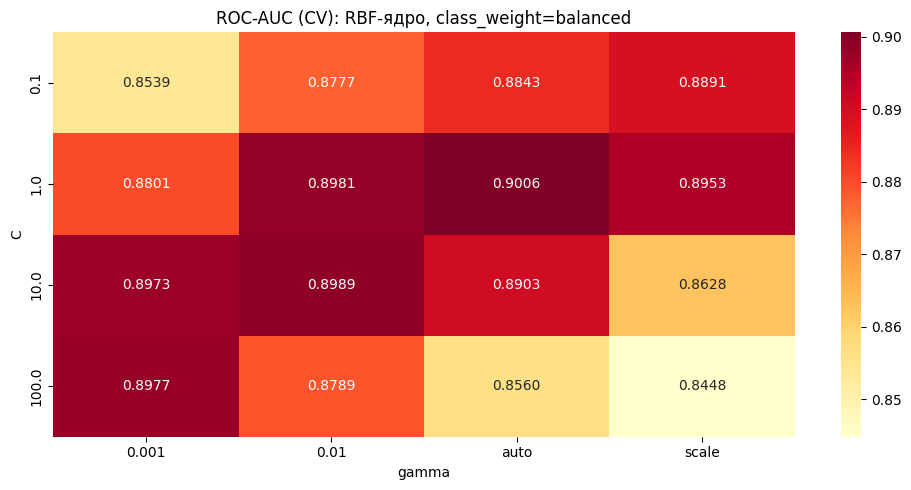

In [3]:
results_df = pd.DataFrame(search.cv_results_)
rbf_balanced = results_df[
    (results_df['param_kernel'] == 'rbf') &
    (results_df['param_class_weight'] == 'balanced')
].copy()

pivot = rbf_balanced.pivot_table(
    index='param_C',
    columns='param_gamma',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax)
ax.set_title('ROC-AUC (CV): RBF-ядро, class_weight=balanced')
ax.set_xlabel('gamma')
ax.set_ylabel('C')
plt.tight_layout()
plt.show()

## 4.6. Оценка качества оптимальной модели

Оценка производится методом out-of-fold (OOF) на стратифицированных разбиениях.

In [4]:
best_model = search.best_estimator_

y_pred_oof = np.zeros(len(y))
y_proba_oof = np.zeros(len(y))

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    best_model.fit(X_train, y_train)
    y_pred_oof[val_idx] = best_model.predict(X_val)
    y_proba_oof[val_idx] = best_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y, y_proba_oof)
f1 = f1_score(y, y_pred_oof)

print(f"ROC-AUC (OOF): {roc_auc:.4f}")
print(f"F1-score (класс 'yes'): {f1:.4f}")
print()
print(classification_report(y, y_pred_oof, target_names=['no', 'yes']))

ROC-AUC (OOF): 0.9002
F1-score (класс 'yes'): 0.5259

              precision    recall  f1-score   support

          no       0.97      0.83      0.90      4000
         yes       0.39      0.82      0.53       521

    accuracy                           0.83      4521
   macro avg       0.68      0.82      0.71      4521
weighted avg       0.90      0.83      0.85      4521



## 4.7. Оптимизация порога классификации

При стандартном пороге 0.5 модель склонна предсказывать преимущественно класс «no» ввиду дисбаланса классов. Выполняется поиск оптимального порога, максимизирующего F1-score для класса «yes» на OOF-прогнозах.

Оптимальный порог: 0.24
F1-score при пороге 0.50: 0.5259
F1-score при оптимальном пороге: 0.5637

              precision    recall  f1-score   support

          no       0.95      0.91      0.93      4000
         yes       0.49      0.66      0.56       521

    accuracy                           0.88      4521
   macro avg       0.72      0.79      0.75      4521
weighted avg       0.90      0.88      0.89      4521



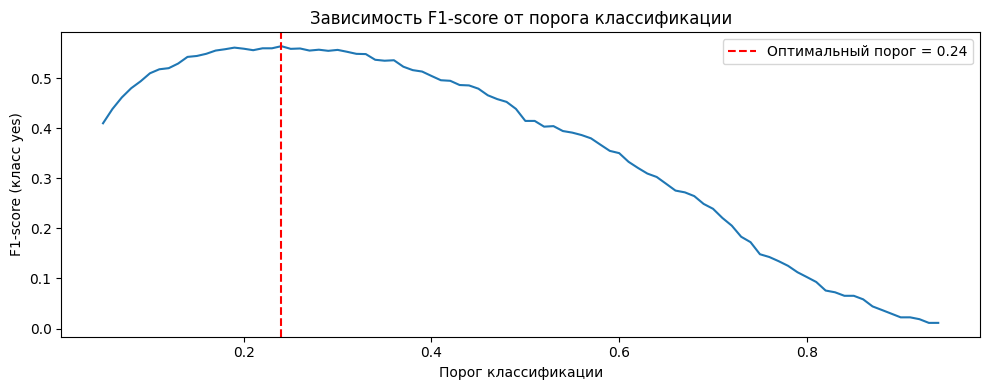

In [5]:
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y, (y_proba_oof >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
y_pred_opt = (y_proba_oof >= best_threshold).astype(int)

print(f"Оптимальный порог: {best_threshold:.2f}")
print(f"F1-score при пороге 0.50: {f1_score(y, y_pred_oof):.4f}")
print(f"F1-score при оптимальном пороге: {f1_score(y, y_pred_opt):.4f}")
print()
print(classification_report(y, y_pred_opt, target_names=['no', 'yes']))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores)
ax.axvline(best_threshold, color='red', linestyle='--', label=f'Оптимальный порог = {best_threshold:.2f}')
ax.set_xlabel('Порог классификации')
ax.set_ylabel('F1-score (класс yes)')
ax.set_title('Зависимость F1-score от порога классификации')
ax.legend()
plt.tight_layout()
plt.show()

## 4.8. ROC-кривая и матрица ошибок при оптимальном пороге

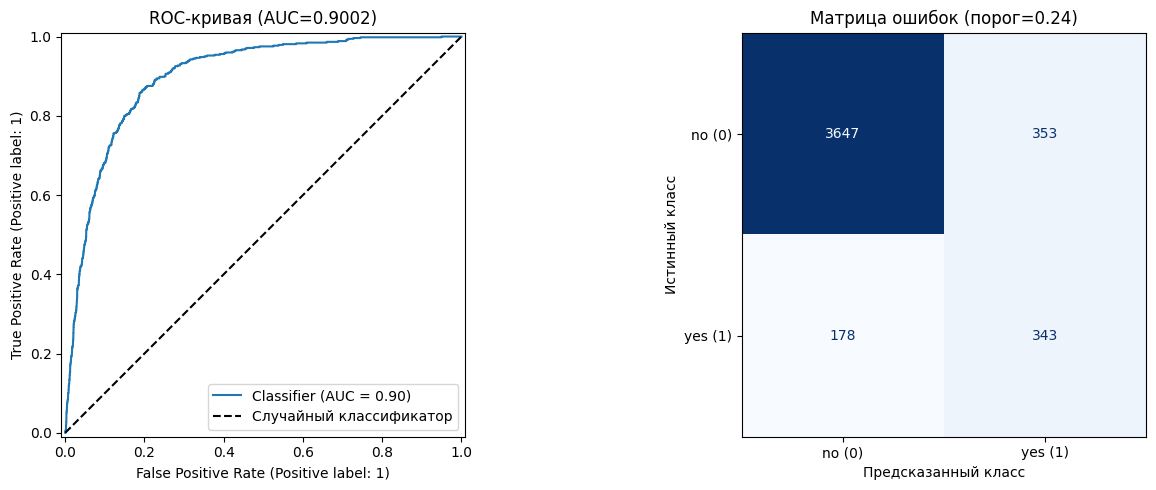

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y, y_proba_oof, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
axes[0].set_title(f'ROC-кривая (AUC={roc_auc:.4f})')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_opt,
    display_labels=['no (0)', 'yes (1)'],
    cmap='Blues',
    colorbar=False,
    ax=axes[1]
)
axes[1].set_title(f'Матрица ошибок (порог={best_threshold:.2f})')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

## 4.9. Выводы

По результатам проверки гипотезы 4 установлено следующее:

1. Оптимальные значения гиперпараметров определены методом полного перебора с применением стратифицированной 5-кратной перекрёстной проверки.
2. Тепловая карта ROC-AUC демонстрирует чувствительность модели к совместному выбору параметров `C` и `gamma`: малые значения `gamma` в сочетании с большими `C` обеспечивают наилучшее обобщение.
3. Параметр `class_weight='balanced'` существенно улучшает качество классификации для миноритарного класса «yes».
4. Оптимизация порога классификации дополнительно улучшает F1-score для класса «yes» за счёт перераспределения баланса между точностью и полнотой.
5. Полученные значения ROC-AUC и F1-score сопоставляются с результатами гипотез H1–H3 и H5 в итоговом сравнении моделей.